#**Perfil dos Estudantes Brasileiros (2019–2023)**

**OBJETIVO**
------------------------------------------------------------------------------
Construir uma base analítica consolidada sobre o perfil dos estudantes
brasileiros dos ensinos Fundamental, Médio e Superior, utilizando dados públicos
do INEP disponibilizados na Base dos Dados e consultados no Google BigQuery.

**DESCRIÇÃO DA SOLUÇÃO**
------------------------------------------------------------------------------
Este script integra dados do Censo Escolar, Censo da Educação Superior e
Diretório de Municípios, criando uma visão única para análise demográfica,
geográfica, institucional, social e de infraestrutura escolar.

A consulta foi desenhada para apoiar estudos de Business Intelligence,
Analytics Educacional, análise exploratória de dados e construção de dashboards.

**FONTES DE DADOS**
------------------------------------------------------------------------------
1. basedosdados.br_inep_censo_escolar.matricula
2. basedosdados.br_inep_censo_escolar.escola
3. basedosdados.br_inep_censo_educacao_superior.curso
4. basedosdados.br_inep_censo_educacao_superior.ies
5. basedosdados.br_bd_diretorios_brasil.municipio

**PERÍODO ANALISADO**
------------------------------------------------------------------------------
2019 a 2023.

###**1. Preparação do Ambiente**

###### **Importação das bibliotecas**

In [17]:
# Instalação da biblioteca basedosdados, se ainda não estiver instalada
!pip install basedosdados

# Importação das bibliotecas necessárias para análise e visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
import basedosdados as bd
import pandas as pd
from google.cloud import bigquery

# Configuração do ID do projeto GCP para faturamento gratuito do BigQuery
# Substitua 'estudosdados-489915' pelo seu próprio ID de projeto, se necessário
project_id = 'estudosdados-489915'

###### **Carga SQL**

In [18]:
query = """

-- Parâmetro inicial do período analisado.
DECLARE ano_inicio INT64 DEFAULT 2019;

-- Parâmetro final do período analisado.
DECLARE ano_fim INT64 DEFAULT 2023;


/*==============================================================================
CTE: educacao_basica
------------------------------------------------------------------------------
Consolida dados da Educação Básica: Ensino Fundamental e Ensino Médio.
==============================================================================*/
WITH educacao_basica AS (
  SELECT
    m.ano,
    'CENSO_ESCOLAR' AS fonte,

    -- Classificação das etapas de ensino.
    CASE
      WHEN CAST(m.etapa_ensino AS STRING) IN ('14','15','16','17','18','19','20','21','41') THEN 'ENSINO_FUNDAMENTAL'
      WHEN CAST(m.etapa_ensino AS STRING) IN ('25','26','27','28','29','30','31','32','33','34','35','36','37','38') THEN 'ENSINO_MEDIO'
      ELSE 'OUTRA_ETAPA'
    END AS nivel_ensino,

    m.sigla_uf,
    m.id_municipio,
    mun.nome AS nome_municipio,

    CAST(m.id_escola AS STRING) AS id_unidade_ensino,
    CAST(NULL AS STRING) AS nome_unidade_ensino,
    CAST(NULL AS STRING) AS id_curso,
    CAST(NULL AS STRING) AS nome_curso,
    CAST(NULL AS STRING) AS area_conhecimento,

    m.sexo,
    m.raca_cor,
    m.idade,
    m.nacionalidade,

    -- Tradução do código da rede de ensino da Educação Básica.
    CASE
      WHEN CAST(m.rede AS STRING) = '1' THEN 'Federal'
      WHEN CAST(m.rede AS STRING) = '2' THEN 'Estadual'
      WHEN CAST(m.rede AS STRING) = '3' THEN 'Municipal'
      WHEN CAST(m.rede AS STRING) = '4' THEN 'Privada'
      ELSE 'Não Informado'
    END AS rede,

    e.tipo_localizacao,
    e.tipo_localizacao_diferenciada,

    CAST(NULL AS STRING) AS tipo_modalidade_ensino,
    CAST(NULL AS STRING) AS tipo_grau_academico,
    CAST(NULL AS STRING) AS tipo_organizacao_academica,
    CAST(NULL AS STRING) AS tipo_organizacao_administrativa,

    -- Métrica principal da Educação Básica.
    COUNT(*) AS qtd_estudantes,

    -- Indicadores de inclusão e transporte.
    COUNTIF(CAST(m.necessidade_especial AS STRING) IN ('1','true','TRUE')) AS qtd_com_deficiencia,
    COUNTIF(CAST(m.transporte_publico AS STRING) IN ('1','true','TRUE')) AS qtd_usa_transporte_publico,

    -- Indicadores de infraestrutura escolar.
    COUNTIF(CAST(e.agua_potavel AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_agua_potavel,
    COUNTIF(CAST(e.energia_rede_publica AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_energia_rede_publica,
    COUNTIF(CAST(e.esgoto_rede_publica AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_esgoto_rede_publica,
    COUNTIF(CAST(e.internet AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_internet,
    COUNTIF(CAST(e.internet_alunos AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_internet_alunos,
    COUNTIF(CAST(e.biblioteca AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_biblioteca,
    COUNTIF(CAST(e.biblioteca_sala_leitura AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_biblioteca_sala_leitura,
    COUNTIF(CAST(e.laboratorio_informatica AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_lab_informatica,
    COUNTIF(CAST(e.laboratorio_ciencias AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_lab_ciencias,
    COUNTIF(CAST(e.quadra_esportes AS STRING) IN ('1','true','TRUE')) AS qtd_em_escola_com_quadra,

    -- Campos exclusivos do Ensino Superior.
    CAST(NULL AS INT64) AS qtd_financiamento,
    CAST(NULL AS INT64) AS qtd_reserva_vaga,
    CAST(NULL AS INT64) AS qtd_apoio_social,
    CAST(NULL AS INT64) AS qtd_atividade_extracurricular,
    CAST(NULL AS INT64) AS qtd_mobilidade_academica

  FROM `basedosdados.br_inep_censo_escolar.matricula` AS m

  LEFT JOIN `basedosdados.br_inep_censo_escolar.escola` AS e
    ON m.ano = e.ano
   AND m.id_escola = e.id_escola

  LEFT JOIN `basedosdados.br_bd_diretorios_brasil.municipio` AS mun
    ON m.id_municipio = mun.id_municipio

  WHERE m.ano BETWEEN ano_inicio AND ano_fim
    AND CAST(m.etapa_ensino AS STRING) IN (
      '14','15','16','17','18','19','20','21','41',
      '25','26','27','28','29','30','31','32','33','34','35','36','37','38'
    )

  GROUP BY
    m.ano,
    nivel_ensino,
    m.sigla_uf,
    m.id_municipio,
    nome_municipio,
    id_unidade_ensino,
    m.sexo,
    m.raca_cor,
    m.idade,
    m.nacionalidade,
    rede,
    e.tipo_localizacao,
    e.tipo_localizacao_diferenciada
),


/*==============================================================================
CTE: educacao_superior
------------------------------------------------------------------------------
Consolida dados do Ensino Superior.
==============================================================================*/
educacao_superior AS (
  SELECT
    c.ano,
    'CENSO_SUPERIOR' AS fonte,
    'ENSINO_SUPERIOR' AS nivel_ensino,

    c.sigla_uf,
    c.id_municipio,
    mun.nome AS nome_municipio,

    CAST(c.id_ies AS STRING) AS id_unidade_ensino,
    i.nome AS nome_unidade_ensino,
    CAST(c.id_curso AS STRING) AS id_curso,
    c.nome_curso,
    c.nome_area_geral AS area_conhecimento,

    -- Campos demográficos agregados no Ensino Superior.
    'AGREGADO' AS sexo,
    'AGREGADO' AS raca_cor,
    CAST(NULL AS INT64) AS idade,
    'AGREGADO' AS nacionalidade,

    -- Tradução do código da rede de ensino do Ensino Superior.
    CASE
      WHEN CAST(c.rede AS STRING) = '1' THEN 'Pública'
      WHEN CAST(c.rede AS STRING) = '2' THEN 'Privada'
      ELSE 'Não Informado'
    END AS rede,

    CAST(NULL AS STRING) AS tipo_localizacao,
    CAST(NULL AS STRING) AS tipo_localizacao_diferenciada,

    c.tipo_modalidade_ensino,
    c.tipo_grau_academico,
    c.tipo_organizacao_academica,
    c.tipo_organizacao_administrativa,

    -- Métrica principal do Ensino Superior.
    SUM(c.quantidade_matriculas) AS qtd_estudantes,

    -- Indicador de inclusão no Ensino Superior.
    SUM(c.quantidade_matriculas_deficiencia) AS qtd_com_deficiencia,

    CAST(NULL AS INT64) AS qtd_usa_transporte_publico,

    -- Campos de infraestrutura aplicáveis apenas à Educação Básica.
    CAST(NULL AS INT64) AS qtd_em_escola_com_agua_potavel,
    CAST(NULL AS INT64) AS qtd_em_escola_com_energia_rede_publica,
    CAST(NULL AS INT64) AS qtd_em_escola_com_esgoto_rede_publica,
    CAST(NULL AS INT64) AS qtd_em_escola_com_internet,
    CAST(NULL AS INT64) AS qtd_em_escola_com_internet_alunos,
    CAST(NULL AS INT64) AS qtd_em_escola_com_biblioteca,
    CAST(NULL AS INT64) AS qtd_em_escola_com_biblioteca_sala_leitura,
    CAST(NULL AS INT64) AS qtd_em_escola_com_lab_informatica,
    CAST(NULL AS INT64) AS qtd_em_escola_com_lab_ciencias,
    CAST(NULL AS INT64) AS qtd_em_escola_com_quadra,

    -- Indicadores específicos do Ensino Superior.
    SUM(c.quantidade_matriculas_financiamento) AS qtd_financiamento,
    SUM(c.quantidade_matriculas_reserva_vaga) AS qtd_reserva_vaga,
    SUM(c.quantidade_matriculas_apoio_social) AS qtd_apoio_social,
    SUM(c.quantidade_matriculas_atividade_extracurricular) AS qtd_atividade_extracurricular,
    SUM(c.quantidade_matriculas_mobilidade_academica) AS qtd_mobilidade_academica

  FROM `basedosdados.br_inep_censo_educacao_superior.curso` AS c

  LEFT JOIN `basedosdados.br_inep_censo_educacao_superior.ies` AS i
    ON c.ano = i.ano
   AND c.id_ies = i.id_ies

  LEFT JOIN `basedosdados.br_bd_diretorios_brasil.municipio` AS mun
    ON c.id_municipio = mun.id_municipio

  WHERE c.ano BETWEEN ano_inicio AND ano_fim

  GROUP BY
    c.ano,
    c.sigla_uf,
    c.id_municipio,
    nome_municipio,
    id_unidade_ensino,
    nome_unidade_ensino,
    id_curso,
    c.nome_curso,
    area_conhecimento,
    rede,
    c.tipo_modalidade_ensino,
    c.tipo_grau_academico,
    c.tipo_organizacao_academica,
    c.tipo_organizacao_administrativa
),


/*==============================================================================
CTE: base_unificada
------------------------------------------------------------------------------
Une os dados da Educação Básica e do Ensino Superior.
==============================================================================*/
base_unificada AS (
  SELECT * FROM educacao_basica
  UNION ALL
  SELECT * FROM educacao_superior
)


/*==============================================================================
RESULTADO FINAL
------------------------------------------------------------------------------
Consolida os dados em uma tabela analítica única para uso em BI.
==============================================================================*/
SELECT
  ano,
  fonte,
  nivel_ensino,
  sigla_uf,
  id_municipio,
  nome_municipio,

  -- Classificação da região geográfica.
  CASE
    WHEN sigla_uf IN ('AC','AP','AM','PA','RO','RR','TO') THEN 'NORTE'
    WHEN sigla_uf IN ('AL','BA','CE','MA','PB','PE','PI','RN','SE') THEN 'NORDESTE'
    WHEN sigla_uf IN ('DF','GO','MT','MS') THEN 'CENTRO-OESTE'
    WHEN sigla_uf IN ('ES','MG','RJ','SP') THEN 'SUDESTE'
    WHEN sigla_uf IN ('PR','RS','SC') THEN 'SUL'
    ELSE 'NAO_IDENTIFICADO'
  END AS regiao,

  sexo,
  raca_cor,

  -- Criação de faixas etárias.
  CASE
    WHEN idade IS NULL THEN 'AGREGADO_SUPERIOR'
    WHEN idade BETWEEN 0 AND 5 THEN '00 A 05'
    WHEN idade BETWEEN 6 AND 10 THEN '06 A 10'
    WHEN idade BETWEEN 11 AND 14 THEN '11 A 14'
    WHEN idade BETWEEN 15 AND 17 THEN '15 A 17'
    WHEN idade BETWEEN 18 AND 24 THEN '18 A 24'
    WHEN idade BETWEEN 25 AND 29 THEN '25 A 29'
    WHEN idade BETWEEN 30 AND 34 THEN '30 A 34'
    WHEN idade BETWEEN 35 AND 39 THEN '35 A 39'
    WHEN idade BETWEEN 40 AND 49 THEN '40 A 49'
    WHEN idade BETWEEN 50 AND 59 THEN '50 A 59'
    WHEN idade >= 60 THEN '60+'
    ELSE 'NAO_INFORMADO'
  END AS faixa_etaria,

  nacionalidade,
  rede,
  tipo_localizacao,
  tipo_localizacao_diferenciada,
  tipo_modalidade_ensino,
  tipo_grau_academico,
  tipo_organizacao_academica,
  tipo_organizacao_administrativa,
  area_conhecimento,

  -- Métricas principais.
  SUM(qtd_estudantes) AS qtd_estudantes,
  SUM(qtd_com_deficiencia) AS qtd_com_deficiencia,
  SUM(qtd_usa_transporte_publico) AS qtd_usa_transporte_publico,

  -- Métricas de infraestrutura escolar.
  SUM(qtd_em_escola_com_agua_potavel) AS qtd_em_escola_com_agua_potavel,
  SUM(qtd_em_escola_com_energia_rede_publica) AS qtd_em_escola_com_energia_rede_publica,
  SUM(qtd_em_escola_com_esgoto_rede_publica) AS qtd_em_escola_com_esgoto_rede_publica,
  SUM(qtd_em_escola_com_internet) AS qtd_em_escola_com_internet,
  SUM(qtd_em_escola_com_internet_alunos) AS qtd_em_escola_com_internet_alunos,
  SUM(qtd_em_escola_com_biblioteca) AS qtd_em_escola_com_biblioteca,
  SUM(qtd_em_escola_com_biblioteca_sala_leitura) AS qtd_em_escola_com_biblioteca_sala_leitura,
  SUM(qtd_em_escola_com_lab_informatica) AS qtd_em_escola_com_lab_informatica,
  SUM(qtd_em_escola_com_lab_ciencias) AS qtd_em_escola_com_lab_ciencias,
  SUM(qtd_em_escola_com_quadra) AS qtd_em_escola_com_quadra,

  -- Métricas específicas do Ensino Superior.
  SUM(qtd_financiamento) AS qtd_financiamento,
  SUM(qtd_reserva_vaga) AS qtd_reserva_vaga,
  SUM(qtd_apoio_social) AS qtd_apoio_social,
  SUM(qtd_atividade_extracurricular) AS qtd_atividade_extracurricular,
  SUM(qtd_mobilidade_academica) AS qtd_mobilidade_academica,

  -- Indicadores percentuais.
  ROUND(SAFE_DIVIDE(SUM(qtd_com_deficiencia), SUM(qtd_estudantes)) * 100, 2) AS perc_com_deficiencia,
  ROUND(SAFE_DIVIDE(SUM(qtd_usa_transporte_publico), SUM(qtd_estudantes)) * 100, 2) AS perc_usa_transporte_publico,
  ROUND(SAFE_DIVIDE(SUM(qtd_em_escola_com_internet), SUM(qtd_estudantes)) * 100, 2) AS perc_em_escola_com_internet,
  ROUND(SAFE_DIVIDE(SUM(qtd_em_escola_com_biblioteca), SUM(qtd_estudantes)) * 100, 2) AS perc_em_escola_com_biblioteca,
  ROUND(SAFE_DIVIDE(SUM(qtd_em_escola_com_lab_informatica), SUM(qtd_estudantes)) * 100, 2) AS perc_em_escola_com_lab_informatica,
  ROUND(SAFE_DIVIDE(SUM(qtd_em_escola_com_quadra), SUM(qtd_estudantes)) * 100, 2) AS perc_em_escola_com_quadra,
  ROUND(SAFE_DIVIDE(SUM(qtd_financiamento), SUM(qtd_estudantes)) * 100, 2) AS perc_financiamento,
  ROUND(SAFE_DIVIDE(SUM(qtd_reserva_vaga), SUM(qtd_estudantes)) * 100, 2) AS perc_reserva_vaga,
  ROUND(SAFE_DIVIDE(SUM(qtd_apoio_social), SUM(qtd_estudantes)) * 100, 2) AS perc_apoio_social,
  ROUND(SAFE_DIVIDE(SUM(qtd_atividade_extracurricular), SUM(qtd_estudantes)) * 100, 2) AS perc_atividade_extracurricular,
  ROUND(SAFE_DIVIDE(SUM(qtd_mobilidade_academica), SUM(qtd_estudantes)) * 100, 2) AS perc_mobilidade_academica

FROM base_unificada

GROUP BY
  ano,
  fonte,
  nivel_ensino,
  sigla_uf,
  id_municipio,
  nome_municipio,
  regiao,
  sexo,
  raca_cor,
  faixa_etaria,
  nacionalidade,
  rede,
  tipo_localizacao,
  tipo_localizacao_diferenciada,
  tipo_modalidade_ensino,
  tipo_grau_academico,
  tipo_organizacao_academica,
  tipo_organizacao_administrativa,
  area_conhecimento

ORDER BY
  ano,
  regiao,
  sigla_uf,
  nome_municipio,
  nivel_ensino,
  qtd_estudantes DESC;

"""
# df_001 >> DataFrame 001
# Executa a query SQL utilizando a biblioteca basedosdados e armazena o resultado em um DataFrame pandas (df_001)
df_001 = bd.read_sql(query, billing_project_id=project_id)
# Imprime as dimensões (linhas, colunas) do DataFrame carregado
print(df_001.shape)

Downloading: 100%|██████████|
(1648945, 48)


###**2. Consultas e Análises**

**Missão:** Construir uma base analítica consolidada sobre o perfil dos estudantes brasileiros dos ensinos Fundamental, Médio e Superior, utilizando dados públicos do INEP disponibilizados na Base dos Dados e consultados no Google BigQuery. Esta análise visa identificar padrões demográficos, geográficos, institucionais, sociais e de infraestrutura escolar para gerar insights que apoiem decisões de políticas públicas e planejamento educacional.

###### **Análise Exploratória**

In [19]:
# Exibe um resumo conciso do DataFrame, incluindo o tipo de dado de cada coluna e a contagem de valores não nulos
df_001.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1648945 entries, 0 to 1648944
Data columns (total 48 columns):
 #   Column                                     Non-Null Count    Dtype  
---  ------                                     --------------    -----  
 0   ano                                        1648945 non-null  Int64  
 1   fonte                                      1648945 non-null  object 
 2   nivel_ensino                               1648945 non-null  object 
 3   sigla_uf                                   1648153 non-null  object 
 4   id_municipio                               1648330 non-null  object 
 5   nome_municipio                             1648153 non-null  object 
 6   regiao                                     1648945 non-null  object 
 7   sexo                                       1648945 non-null  object 
 8   raca_cor                                   1648945 non-null  object 
 9   faixa_etaria                               1648945 non-null  object 

In [20]:
# Exibe as primeiras 5 linhas do DataFrame para uma visualização rápida dos dados
df_001.head()

,ano,fonte,nivel_ensino,sigla_uf,id_municipio,nome_municipio,regiao,sexo,raca_cor,faixa_etaria,...,perc_usa_transporte_publico,perc_em_escola_com_internet,perc_em_escola_com_biblioteca,perc_em_escola_com_lab_informatica,perc_em_escola_com_quadra,perc_financiamento,perc_reserva_vaga,perc_apoio_social,perc_atividade_extracurricular,perc_mobilidade_academica
0,2019,CENSO_ESCOLAR,ENSINO_FUNDAMENTAL,DF,5300108,Brasília,CENTRO-OESTE,1,3,11 A 14,...,9.74,99.50,31.16,70.32,88.42,NaN,NaN,NaN,NaN,NaN
1,2019,CENSO_ESCOLAR,ENSINO_FUNDAMENTAL,DF,5300108,Brasília,CENTRO-OESTE,2,3,11 A 14,...,10.08,99.54,31.80,70.53,89.32,NaN,NaN,NaN,NaN,NaN
2,2019,CENSO_ESCOLAR,ENSINO_FUNDAMENTAL,DF,5300108,Brasília,CENTRO-OESTE,1,3,06 A 10,...,10.41,98.99,18.47,72.37,71.80,NaN,NaN,NaN,NaN,NaN
3,2019,CENSO_ESCOLAR,ENSINO_FUNDAMENTAL,DF,5300108,Brasília,CENTRO-OESTE,2,3,06 A 10,...,9.99,98.94,18.62,72.32,71.96,NaN,NaN,NaN,NaN,NaN
4,2019,CENSO_ESCOLAR,ENSINO_FUNDAMENTAL,DF,5300108,Brasília,CENTRO-OESTE,1,0,06 A 10,...,12.13,96.74,19.36,68.51,74.51,NaN,NaN,NaN,NaN,NaN


In [21]:
# Gera estatísticas descritivas das colunas numéricas do DataFrame, como contagem, média, desvio padrão, mínimo, máximo e quartis
df_001.describe()

,ano,qtd_estudantes,qtd_com_deficiencia,qtd_usa_transporte_publico,qtd_em_escola_com_agua_potavel,qtd_em_escola_com_energia_rede_publica,qtd_em_escola_com_esgoto_rede_publica,qtd_em_escola_com_internet,qtd_em_escola_com_internet_alunos,qtd_em_escola_com_biblioteca,...,perc_usa_transporte_publico,perc_em_escola_com_internet,perc_em_escola_com_biblioteca,perc_em_escola_com_lab_informatica,perc_em_escola_com_quadra,perc_financiamento,perc_reserva_vaga,perc_apoio_social,perc_atividade_extracurricular,perc_mobilidade_academica
count,1648945.0,1648945.0,1648945.0,1280425.0,1280425.0,1280425.0,1280425.0,1280425.0,1280425.0,1280425.0,...,1.280425e+06,1.280425e+06,1.280425e+06,1.280425e+06,1.280425e+06,338245.000000,338245.000000,338245.000000,338245.000000,338245.000000
mean,2019.891145,69.349268,1.462594,11.004517,51.218303,53.205618,37.202548,49.627025,26.963956,31.282276,...,3.380089e+01,9.009371e+01,5.946016e+01,5.912272e+01,5.898522e+01,29.447749,2.079769,9.649715,12.875910,0.024071
std,1.083872,509.793613,11.22806,165.927973,457.532077,461.904123,427.076536,434.190563,257.745504,264.514247,...,3.785719e+01,2.722665e+01,4.557166e+01,4.519796e+01,4.513079e+01,35.835826,9.202153,24.605937,27.505222,1.277865
min,2019.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020.0,6.0,0.0,1.0,5.0,5.0,1.0,4.0,1.0,2.0,...,1.816000e+01,1.000000e+02,9.458000e+01,8.871000e+01,8.667000e+01,11.110000,0.000000,0.000000,0.000000,0.000000
75%,2020.0,29.0,1.0,6.0,23.0,24.0,8.0,22.0,8.0,11.0,...,6.429000e+01,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,53.060000,0.000000,0.000000,7.840000,0.000000
max,2023.0,63987.0,2107.0,50497.0,62133.0,62133.0,59846.0,59052.0,40325.0,34793.0,...,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000


###### **Análise Segmentadas**

In [22]:
# Obtém os valores únicos da coluna 'ano' para identificar os anos presentes no DataFrame
anos_na_tabela = df_001['ano'].unique()

# Imprime a lista de anos encontrados na tabela, ordenados
print("Anos encontrados na tabela:")
print(sorted(anos_na_tabela))

Anos encontrados na tabela:
[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


### **3. Análises e Visualizações**

Vamos começar com algumas análises básicas para entender a distribuição dos dados.

#### **3.1. Evolução do Número de Estudantes por Ano e Nível de Ensino**

Esta análise nos permite visualizar como o número de estudantes se distribuiu e evoluiu entre os diferentes níveis de ensino ao longo do tempo.

,ano,nivel_ensino,qtd_estudantes
0,2019,ENSINO_FUNDAMENTAL,26923730
1,2019,ENSINO_MEDIO,7465891
2,2019,ENSINO_SUPERIOR,8604526
3,2020,ENSINO_FUNDAMENTAL,26718830
4,2020,ENSINO_MEDIO,7550753


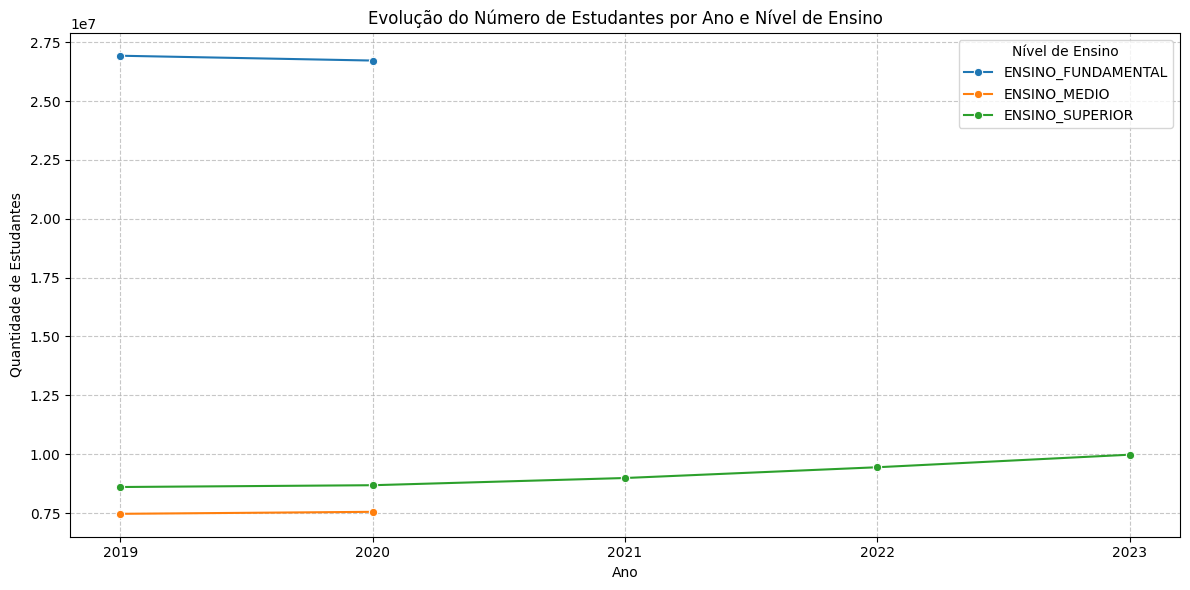

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupa os dados por 'ano' e 'nivel_ensino' e soma a 'qtd_estudantes' para cada grupo
estudantes_por_ano_nivel = df_001.groupby(['ano', 'nivel_ensino'])['qtd_estudantes'].sum().reset_index()

# Exibe as primeiras linhas da tabela resultante para ver a estrutura dos dados agrupados
display(estudantes_por_ano_nivel.head())

# Cria uma figura para o gráfico com tamanho especificado
plt.figure(figsize=(12, 6))
# Gera um gráfico de linha mostrando a evolução da quantidade de estudantes por ano, diferenciado por nível de ensino
sns.lineplot(data=estudantes_por_ano_nivel, x='ano', y='qtd_estudantes', hue='nivel_ensino', marker='o')
plt.title('Evolução do Número de Estudantes por Ano e Nível de Ensino') # Define o título do gráfico
plt.xlabel('Ano') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade ao gráfico para facilitar a leitura
plt.xticks(estudantes_por_ano_nivel['ano'].unique()) # Define os ticks do eixo X com os anos únicos
plt.legend(title='Nível de Ensino') # Adiciona uma legenda com o título 'Nível de Ensino'
plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.show() # Exibe o gráfico

#### **3.2. Distribuição Regional de Estudantes**

Vamos analisar como a quantidade de estudantes se distribui pelas diferentes regiões do Brasil.

,ano,regiao,nivel_ensino,qtd_estudantes
0,2019,CENTRO-OESTE,ENSINO_FUNDAMENTAL,2119110
1,2019,CENTRO-OESTE,ENSINO_MEDIO,593504
2,2019,CENTRO-OESTE,ENSINO_SUPERIOR,787751
3,2019,NAO_IDENTIFICADO,ENSINO_SUPERIOR,1859
4,2019,NORDESTE,ENSINO_FUNDAMENTAL,7889261


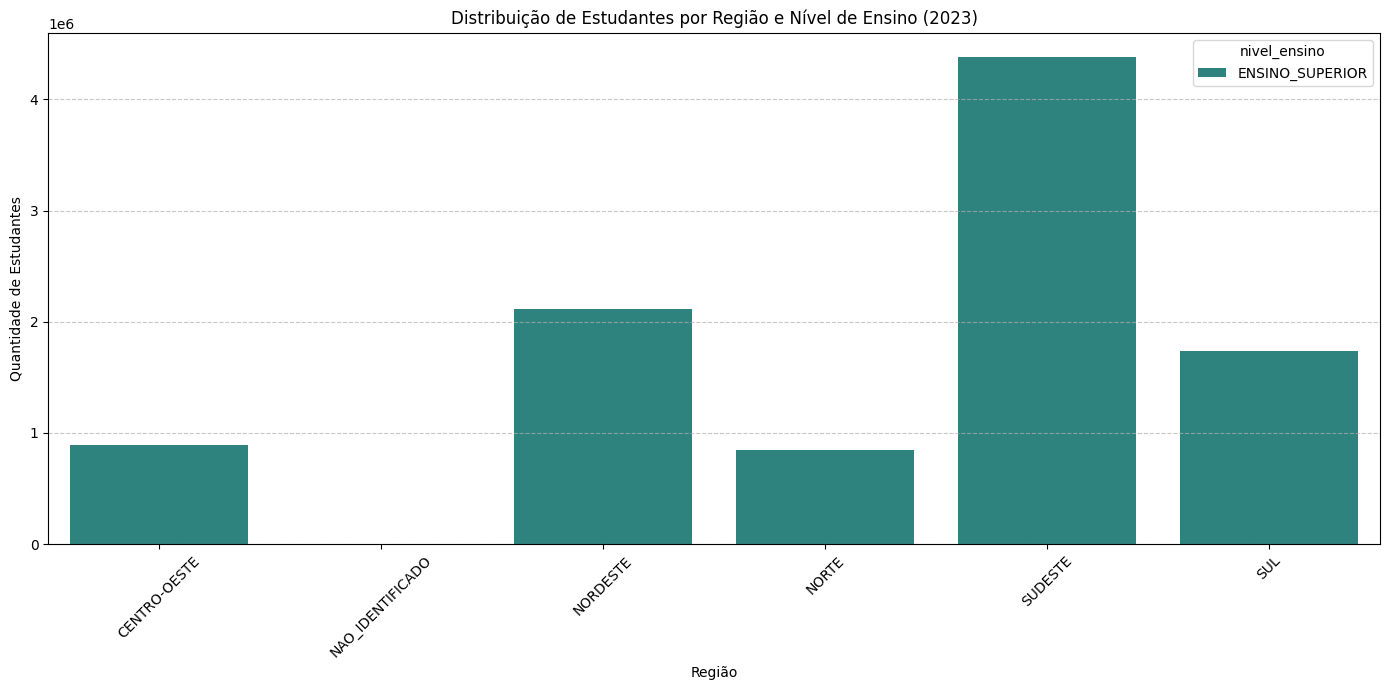

In [24]:
# Agrupa os dados por 'ano', 'regiao' e 'nivel_ensino' e soma a 'qtd_estudantes' para cada grupo
estudantes_por_regiao = df_001.groupby(['ano', 'regiao', 'nivel_ensino'])['qtd_estudantes'].sum().reset_index()

# Exibe as primeiras linhas da tabela resultante
display(estudantes_por_regiao.head())

# Obtém o último ano disponível nos dados
ultimo_ano = df_001['ano'].max()
# Filtra os dados para considerar apenas o último ano disponível
estudantes_regiao_ultimo_ano = estudantes_por_regiao[estudantes_por_regiao['ano'] == ultimo_ano]

# Cria uma figura para o gráfico com tamanho especificado
plt.figure(figsize=(14, 7))
# Gera um gráfico de barras mostrando a distribuição de estudantes por região, diferenciado por nível de ensino
sns.barplot(data=estudantes_regiao_ultimo_ano, x='regiao', y='qtd_estudantes', hue='nivel_ensino', palette='viridis')
plt.title(f'Distribuição de Estudantes por Região e Nível de Ensino ({ultimo_ano})') # Define o título do gráfico com o ano
plt.xlabel('Região') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.3. Acesso à Internet nas Escolas por Nível de Ensino e Ano**

Um indicador crucial é o percentual de estudantes em escolas com acesso à internet, que reflete as condições de infraestrutura para o aprendizado.

,ano,nivel_ensino,perc_em_escola_com_internet
0,2019,ENSINO_FUNDAMENTAL,86.789387
1,2019,ENSINO_MEDIO,92.574937
2,2020,ENSINO_FUNDAMENTAL,89.975452
3,2020,ENSINO_MEDIO,96.324618


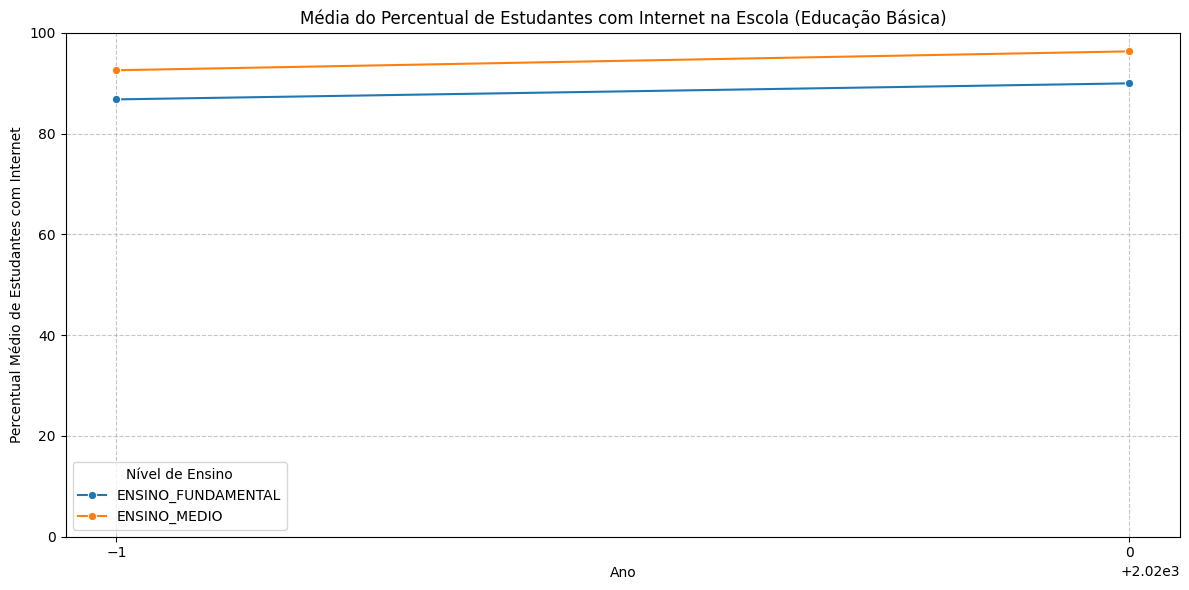

In [25]:
# Filtra os dados para excluir o 'ENSINO_SUPERIOR' (onde 'perc_em_escola_com_internet' pode ser NaN)
# Agrupa os dados restantes por 'ano' e 'nivel_ensino' e calcula a média do 'perc_em_escola_com_internet'
internet_escola_basic = df_001[df_001['nivel_ensino'] != 'ENSINO_SUPERIOR'].groupby(['ano', 'nivel_ensino'])['perc_em_escola_com_internet'].mean().reset_index()

# Exibe as primeiras linhas da tabela resultante
display(internet_escola_basic.head())

# Cria uma figura para o gráfico com tamanho especificado
plt.figure(figsize=(12, 6))
# Gera um gráfico de linha mostrando a evolução do percentual médio de estudantes com internet na escola
sns.lineplot(data=internet_escola_basic, x='ano', y='perc_em_escola_com_internet', hue='nivel_ensino', marker='o')
plt.title('Média do Percentual de Estudantes com Internet na Escola (Educação Básica)') # Define o título do gráfico
plt.xlabel('Ano') # Define o rótulo do eixo X
plt.ylabel('Percentual Médio de Estudantes com Internet') # Define o rótulo do eixo Y
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade ao gráfico
plt.xticks(internet_escola_basic['ano'].unique()) # Define os ticks do eixo X com os anos únicos
plt.legend(title='Nível de Ensino') # Adiciona uma legenda
plt.ylim(0, 100) # Define o limite do eixo Y de 0 a 100 para percentuais
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.4. Distribuição de Estudantes por Sexo e Nível de Ensino**

Vamos visualizar a proporção de estudantes masculinos e femininos em cada nível de ensino.

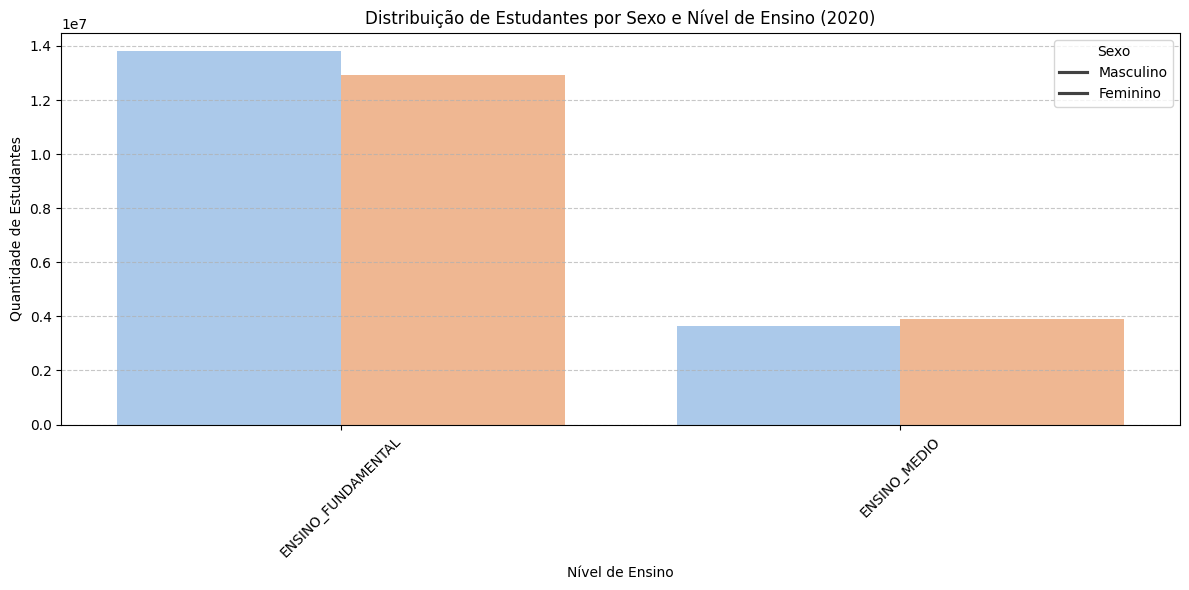

In [26]:
# Filtra o DataFrame para remover entradas onde 'sexo' é 'AGREGADO' (que representa dados já somados ou não detalhados)
estudantes_por_sexo = df_001[df_001['sexo'] != 'AGREGADO'].groupby(['ano', 'nivel_ensino', 'sexo'])['qtd_estudantes'].sum().reset_index()

# Encontra o último ano disponível para focar a análise na situação mais recente
ultimo_ano_sexo = estudantes_por_sexo['ano'].max()
# Filtra os dados para o último ano
estudantes_sexo_ultimo_ano = estudantes_por_sexo[estudantes_por_sexo['ano'] == ultimo_ano_sexo]

# Cria uma figura para o gráfico com um tamanho específico
plt.figure(figsize=(12, 6))
# Gera um gráfico de barras que mostra a quantidade de estudantes por nível de ensino, separados por sexo
sns.barplot(data=estudantes_sexo_ultimo_ano, x='nivel_ensino', y='qtd_estudantes', hue='sexo', palette='pastel')
plt.title(f'Distribuição de Estudantes por Sexo e Nível de Ensino ({ultimo_ano_sexo})') # Define o título do gráfico com o ano
plt.xlabel('Nível de Ensino') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X para evitar sobreposição
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal
plt.legend(title='Sexo', labels=['Masculino', 'Feminino']) # Adiciona uma legenda customizada para o sexo
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.5. Distribuição de Estudantes por Raça/Cor e Nível de Ensino**

Analisar a composição racial/étnica dos estudantes ajuda a identificar padrões de inclusão e desigualdade.

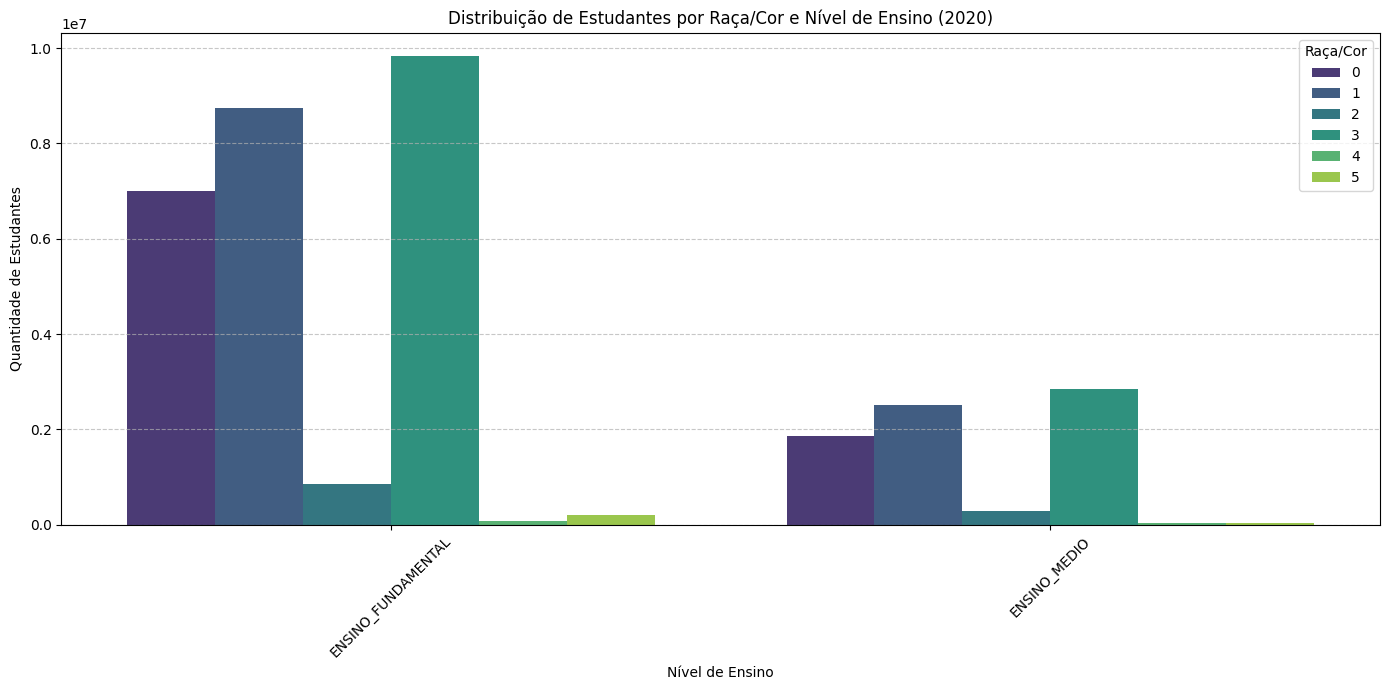

In [27]:
# Filtra o DataFrame para remover entradas onde 'raca_cor' é 'AGREGADO'
estudantes_por_raca = df_001[df_001['raca_cor'] != 'AGREGADO'].groupby(['ano', 'nivel_ensino', 'raca_cor'])['qtd_estudantes'].sum().reset_index()

# Encontra o último ano disponível para focar a análise
ultimo_ano_raca = estudantes_por_raca['ano'].max()
# Filtra os dados para o último ano
estudantes_raca_ultimo_ano = estudantes_por_raca[estudantes_por_raca['ano'] == ultimo_ano_raca]

# Cria uma figura para o gráfico com um tamanho específico
plt.figure(figsize=(14, 7))
# Gera um gráfico de barras que mostra a quantidade de estudantes por nível de ensino, separados por raça/cor
sns.barplot(data=estudantes_raca_ultimo_ano, x='nivel_ensino', y='qtd_estudantes', hue='raca_cor', palette='viridis')
plt.title(f'Distribuição de Estudantes por Raça/Cor e Nível de Ensino ({ultimo_ano_raca})') # Define o título do gráfico com o ano
plt.xlabel('Nível de Ensino') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal
plt.legend(title='Raça/Cor') # Adiciona uma legenda para raça/cor
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.6. Distribuição de Estudantes por Faixa Etária e Nível de Ensino**

Esta análise revela a faixa etária predominante em cada nível de ensino, o que pode indicar a adequação do sistema educacional às diferentes idades.

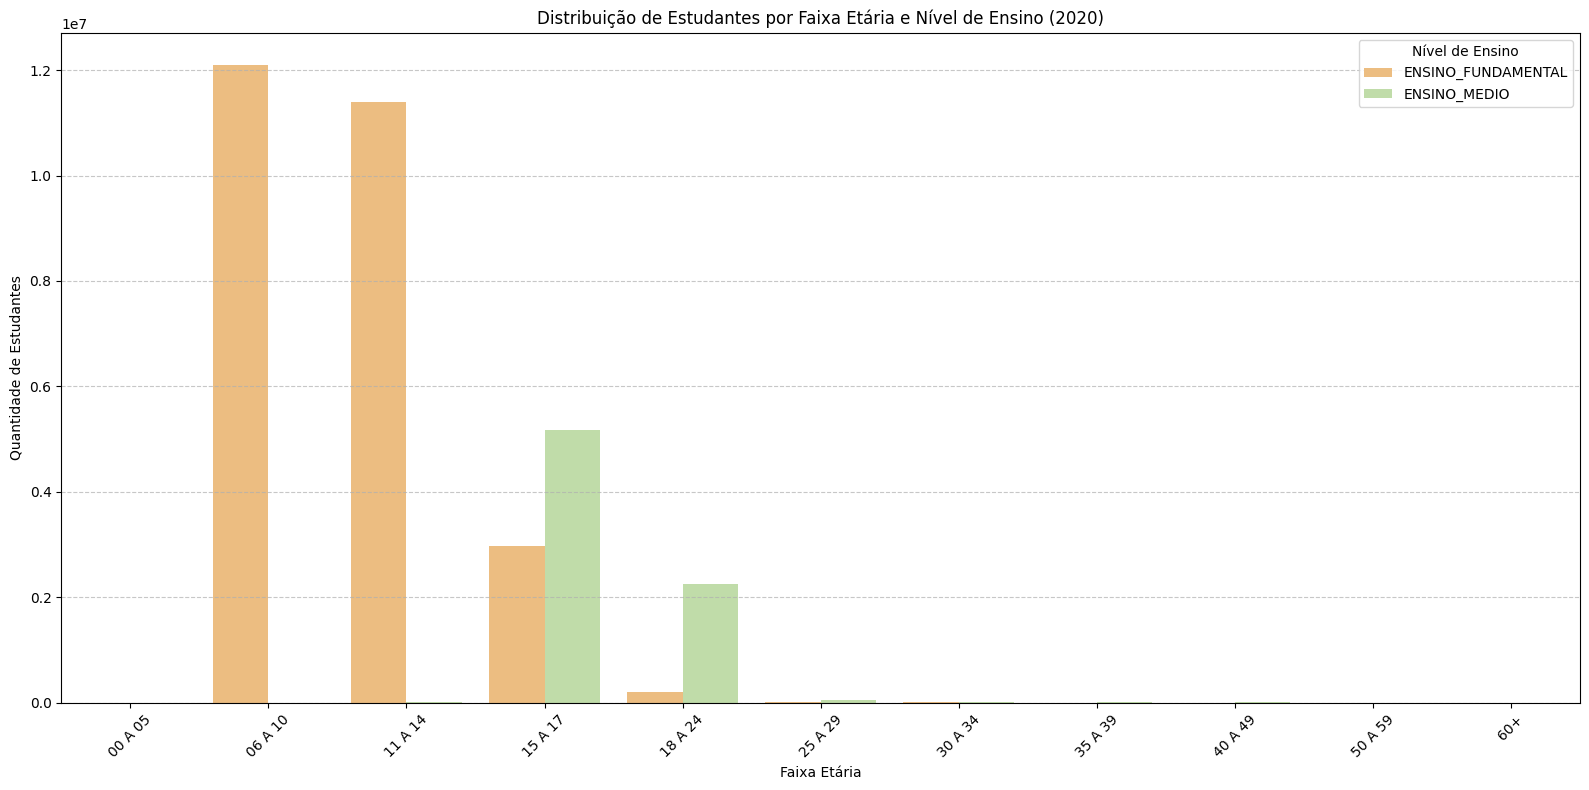

In [28]:
# Filtra o DataFrame para remover entradas onde 'faixa_etaria' é 'AGREGADO_SUPERIOR' (dados agregados ou não detalhados)
estudantes_por_faixa_etaria = df_001[df_001['faixa_etaria'] != 'AGREGADO_SUPERIOR'].groupby(['ano', 'nivel_ensino', 'faixa_etaria'])['qtd_estudantes'].sum().reset_index()

# Encontra o último ano disponível para a análise
ultimo_ano_idade = estudantes_por_faixa_etaria['ano'].max()
# Filtra os dados para o último ano
estudantes_idade_ultimo_ano = estudantes_por_faixa_etaria[estudantes_por_faixa_etaria['ano'] == ultimo_ano_idade]

# Define a ordem correta das faixas etárias para garantir que o gráfico seja ordenado logicamente
ordem_faixas = ['00 A 05', '06 A 10', '11 A 14', '15 A 17', '18 A 24', '25 A 29', '30 A 34', '35 A 39', '40 A 49', '50 A 59', '60+']
estudantes_idade_ultimo_ano['faixa_etaria'] = pd.Categorical(estudantes_idade_ultimo_ano['faixa_etaria'], categories=ordem_faixas, ordered=True)

# Cria uma figura para o gráfico com um tamanho específico
plt.figure(figsize=(16, 8))
# Gera um gráfico de barras que mostra a quantidade de estudantes por faixa etária, separados por nível de ensino
sns.barplot(data=estudantes_idade_ultimo_ano.sort_values('faixa_etaria'), x='faixa_etaria', y='qtd_estudantes', hue='nivel_ensino', palette='Spectral')
plt.title(f'Distribuição de Estudantes por Faixa Etária e Nível de Ensino ({ultimo_ano_idade})') # Define o título do gráfico com o ano
plt.xlabel('Faixa Etária') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal
plt.legend(title='Nível de Ensino') # Adiciona uma legenda
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.7. Percentual de Estudantes com Deficiência por Nível de Ensino e Ano**

Vamos analisar como o percentual de estudantes com deficiência se comporta nos diferentes níveis de ensino ao longo dos anos, para identificar tendências de inclusão.

,ano,nivel_ensino,perc_com_deficiencia
0,2019,ENSINO_FUNDAMENTAL,8.980427
1,2019,ENSINO_MEDIO,2.809795
2,2019,ENSINO_SUPERIOR,0.569261
3,2020,ENSINO_FUNDAMENTAL,8.578084
4,2020,ENSINO_MEDIO,3.148827


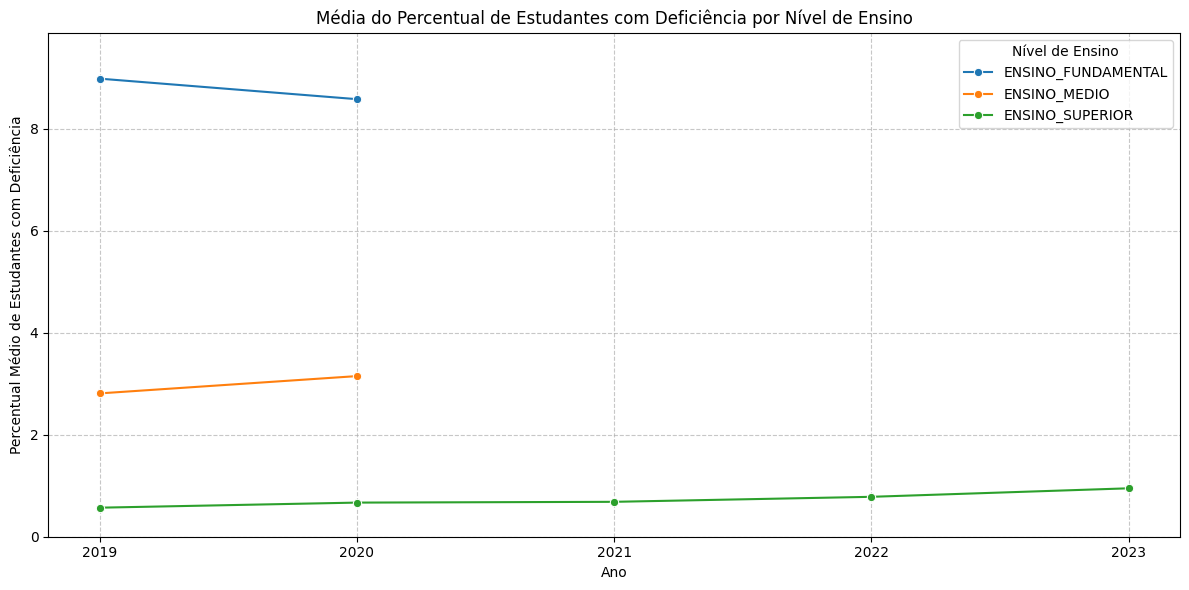

In [29]:
# Agrupa os dados por 'ano' e 'nivel_ensino' e calcula a média do 'perc_com_deficiencia'
deficiencia_por_nivel = df_001.groupby(['ano', 'nivel_ensino'])['perc_com_deficiencia'].mean().reset_index()

# Exibe as primeiras linhas da tabela resultante
display(deficiencia_por_nivel.head())

# Cria uma figura para o gráfico com tamanho especificado
plt.figure(figsize=(12, 6))
# Gera um gráfico de linha mostrando a evolução do percentual médio de estudantes com deficiência
sns.lineplot(data=deficiencia_por_nivel, x='ano', y='perc_com_deficiencia', hue='nivel_ensino', marker='o')
plt.title('Média do Percentual de Estudantes com Deficiência por Nível de Ensino') # Define o título
plt.xlabel('Ano') # Define o rótulo do eixo X
plt.ylabel('Percentual Médio de Estudantes com Deficiência') # Define o rótulo do eixo Y
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade
plt.xticks(deficiencia_por_nivel['ano'].unique()) # Define os ticks do eixo X
plt.legend(title='Nível de Ensino') # Adiciona uma legenda
plt.ylim(0, deficiencia_por_nivel['perc_com_deficiencia'].max() * 1.1) # Ajusta o limite superior do eixo Y
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.8. Comparação entre Redes de Ensino (Pública vs. Privada)**

Agora, vamos investigar a distribuição de estudantes entre as redes pública e privada, e como isso varia por nível de ensino.

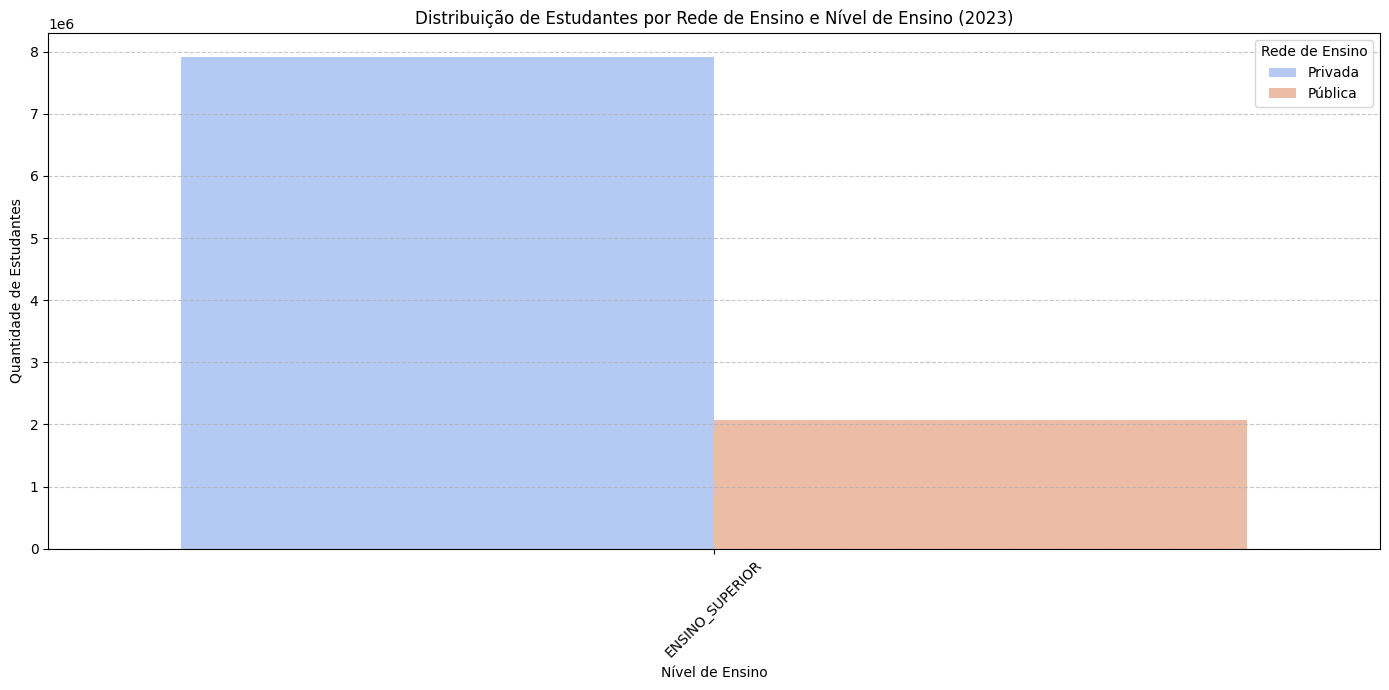

In [30]:
# Filtra o DataFrame para remover entradas onde 'rede' é 'Não Informado'
estudantes_por_rede = df_001[df_001['rede'] != 'Não Informado'].groupby(['ano', 'rede', 'nivel_ensino'])['qtd_estudantes'].sum().reset_index()

# Encontra o último ano disponível para a análise
ultimo_ano_rede = estudantes_por_rede['ano'].max()
# Filtra os dados para o último ano
estudantes_rede_ultimo_ano = estudantes_por_rede[estudantes_por_rede['ano'] == ultimo_ano_rede]

# Cria uma figura para o gráfico com tamanho especificado
plt.figure(figsize=(14, 7))
# Gera um gráfico de barras mostrando a distribuição de estudantes por nível de ensino, separados por rede (pública/privada)
sns.barplot(data=estudantes_rede_ultimo_ano, x='nivel_ensino', y='qtd_estudantes', hue='rede', palette='coolwarm')
plt.title(f'Distribuição de Estudantes por Rede de Ensino e Nível de Ensino ({ultimo_ano_rede})') # Define o título
plt.xlabel('Nível de Ensino') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal
plt.legend(title='Rede de Ensino') # Adiciona uma legenda
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico

#### **3.9. Análise de Apoio e Recursos no Ensino Superior**

Para o Ensino Superior, é relevante analisar as métricas de apoio aos estudantes, como financiamento, reserva de vagas e apoio social.

,ano,qtd_financiamento,qtd_reserva_vaga,qtd_apoio_social,qtd_atividade_extracurricular,qtd_mobilidade_academica
0,2019,2988554,570695,866857,1467722,8366
1,2020,3016846,564210,768317,1290302,8142
2,2021,2646426,621020,764360,1339146,6535
3,2022,2833439,605768,924953,1600696,9795
4,2023,3021709,605591,566092,1562535,8561


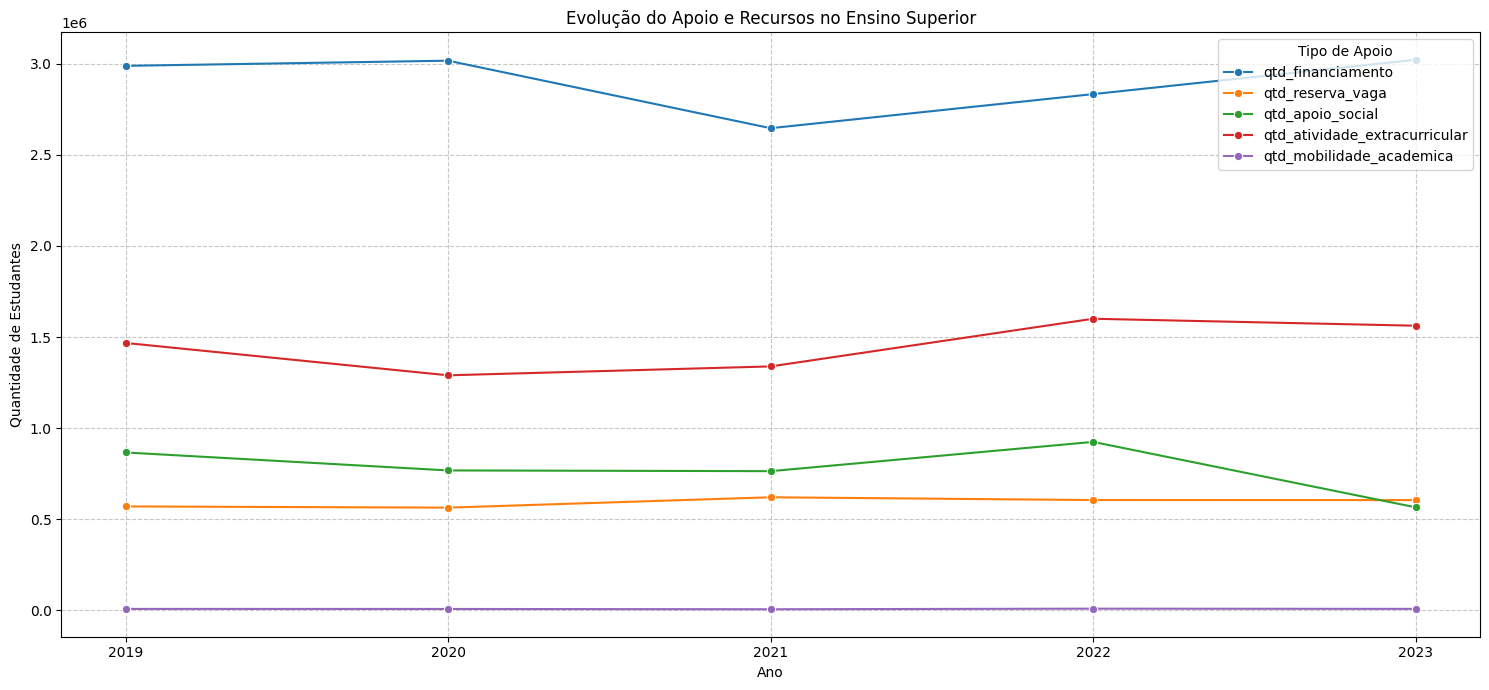

In [31]:
# Filtra o DataFrame para considerar apenas dados do 'ENSINO_SUPERIOR'
# Agrupa por 'ano' e soma as quantidades de diferentes tipos de apoio e recursos
apoio_superior = df_001[df_001['nivel_ensino'] == 'ENSINO_SUPERIOR'].groupby('ano')[['qtd_financiamento', 'qtd_reserva_vaga', 'qtd_apoio_social', 'qtd_atividade_extracurricular', 'qtd_mobilidade_academica']].sum().reset_index()

# Exibe as primeiras linhas da tabela resultante
display(apoio_superior.head())

# Transforma o DataFrame de formato 'wide' para 'long' para facilitar a visualização com seaborn
# Isso empilha as colunas de quantidade de apoio em uma única coluna 'Quantidade de Estudantes'
apoio_superior_long = apoio_superior.melt(id_vars='ano', var_name='Tipo de Apoio', value_name='Quantidade de Estudantes')

# Cria uma figura para o gráfico com tamanho especificado
plt.figure(figsize=(15, 7))
# Gera um gráfico de linha mostrando a evolução dos diferentes tipos de apoio e recursos no Ensino Superior
sns.lineplot(data=apoio_superior_long, x='ano', y='Quantidade de Estudantes', hue='Tipo de Apoio', marker='o')
plt.title('Evolução do Apoio e Recursos no Ensino Superior') # Define o título
plt.xlabel('Ano') # Define o rótulo do eixo X
plt.ylabel('Quantidade de Estudantes') # Define o rótulo do eixo Y
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade
plt.xticks(apoio_superior_long['ano'].unique()) # Define os ticks do eixo X
plt.legend(title='Tipo de Apoio') # Adiciona uma legenda
plt.tight_layout() # Ajusta o layout
plt.show() # Exibe o gráfico